# COVID Test Result Classification

ADTA 4230 Final Project - Benjamin Wilcox, Matthew Flores

## 1. Introduction / Business Understanding

The 2020 COVID-19 pandemic brought a need for the ability to quickly identify infected individuals to make decisions in the interest of controlling the spread of the virus. Laboratory testing provided the most accurate method of diagnosing infected persons; however, laboratory testing proved to be too slow of a process with results sometimes taking upwards of a week. Predicting which individuals were likely high-risk based on patterns of symptoms served as a pivotal tool for healthcare workers. Machine learning can be strategically leveraged to optimize the screening process and determine where to best distribute resources.  
This project uses COVID-19 symptom data. Columns within the dataset map to symptoms and binary values indicate the presence of said symptom where a value of 1 means the symptom is reported. Each tuple (row) is mapped to one patient. The result column is the target variable. The target variable indicates if the patient tested positive or negative for the COVID-19 virus. Since the target variable is binary, this analysis serves to answer a classification problem.
The goal of this analysis is to create models that can accurately classify whether an individual is likely to be diagnosed as positive for the presence of COVID-19 using only the individual’s reported symptoms. Two supervised machine learning models are created to reach this objective which include the following: K-Nearest Neighbors (KNN) and Logistic Regression. The models are compared to determine which of the two is the most reliable in predicting if a patient will be found to have tested positive for COVID-19.  
The models will be analyzed to extrapolate many important insights. We answer the following questions in the order they are presented:
- Which symptom correlates the strongest with a positive COVID-19 result?
- Is symptom data alone sufficient to diagnose an individual?
- Which of the two algorithms provides the best performance when it comes to classification?
The purpose of answering these questions is to give a supplemental tool to healthcare workers.

## 2. Data understanding/EDA

This section analyzes the COVID-19 dataset before preprocessing. The structure of the dataset is identified along with any potential data issues. Relationships between the variables that may affect the models are determined.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_excel('CovidData.xlsx')

### Dataset Overview

In [3]:
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

Number of observations: 1030724
Number of variables: 9


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030724 entries, 0 to 1030723
Data columns (total 9 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   Cough                1030724 non-null  int64
 1   Fever                1030724 non-null  int64
 2   Sore_Throat          1030724 non-null  int64
 3   Shortness_Of_Breath  1030724 non-null  int64
 4   Headache             1030724 non-null  int64
 5   Age_60_And_Above     979736 non-null   str  
 6   Sex                  1028123 non-null  str  
 7   Contact              1030724 non-null  int64
 8   Result               1030724 non-null  str  
dtypes: int64(6), str(3)
memory usage: 70.8 MB


In [5]:
df.head()

,Cough,Fever,Sore_Throat,Shortness_Of_Breath,Headache,Age_60_And_Above,Sex,Contact,Result
0,0,0,0,0,0,No,female,0,negative
1,0,0,0,0,0,No,female,0,negative
2,1,0,0,0,0,No,female,0,negative
3,0,0,0,0,0,No,male,0,negative
4,0,0,0,0,0,No,female,0,negative


In [6]:
df.describe(include='all')

,Cough,Fever,Sore_Throat,Shortness_Of_Breath,Headache,Age_60_And_Above,Sex,Contact,Result
count,1.030724e+06,1.030724e+06,1.030724e+06,1.030724e+06,1.030724e+06,979736,1028123,1.030724e+06,1030724
unique,NaN,NaN,NaN,NaN,NaN,2,2,NaN,2
top,NaN,NaN,NaN,NaN,NaN,No,female,NaN,negative
freq,NaN,NaN,NaN,NaN,NaN,849307,528254,NaN,925290
mean,2.680252e-02,2.717604e-02,8.983006e-03,2.716537e-03,1.888963e-02,NaN,NaN,6.311583e-02,NaN
std,1.615059e-01,1.625962e-01,9.435211e-02,5.204959e-02,1.361354e-01,NaN,NaN,2.431713e-01,NaN
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN


### Missing Values

In [7]:
# Count missing values in every column
missing = df.isnull().sum()

In [8]:
# Display only columns with missing values
missing[missing > 0]

Age_60_And_Above    50988
Sex                  2601
dtype: int64

In [9]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percent Missing": missing_percent
})

missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Percent Missing
Age_60_And_Above,50988,4.946814
Sex,2601,0.252347


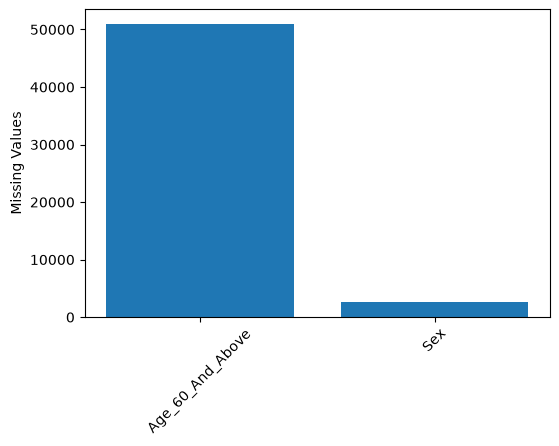

In [10]:
missing_df = missing_df[missing_df["Missing Values"] > 0]

plt.figure(figsize=(6,4))
plt.bar(missing_df.index, missing_df["Missing Values"])
plt.ylabel("Missing Values")
plt.xticks(rotation=45)
plt.savefig("Figure1.png", dpi=300, bbox_inches="tight")
plt.show()

The following two variables contain values with missing values: **Age_60_And_Above** and **Sex**. The **Age_60_And_Above** variable has **50,988 missing** data points (4.95%). **Sex** has **2,601 missing** data points (0.25%). All other columns contain no missing data.

Since the amount of missing values is proportional low to the overall dataset, these values can be dropped during the data preparation stage without dramatically reducing the size of the overall dataset.

### Target Variable

The target variable is checked to see whether the dataset is balanced between positive and negative COVID-19 test results. Balance is important because imbalanced datasets can negatively impact the performance of models.

In [11]:
# Count observations for each COVID-19 test result
result_counts = df["Result"].value_counts()

result_counts

Result
negative    925290
positive    105434
Name: count, dtype: int64

In [12]:
# Percentage of each class
result_percent = df["Result"].value_counts(normalize=True) * 100

result_percent.round(2)

Result
negative    89.77
positive    10.23
Name: proportion, dtype: float64

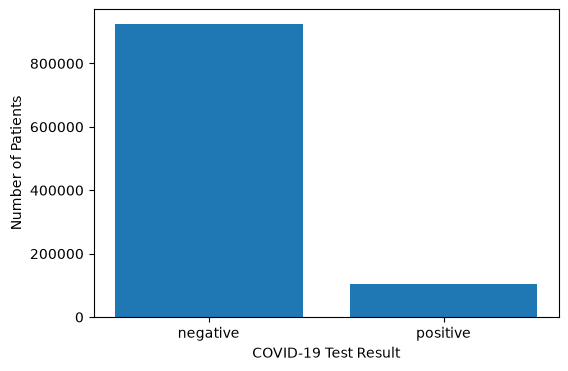

In [13]:
plt.figure(figsize=(6,4))

plt.bar(result_counts.index, result_counts.values)

#plt.title("Distribution of COVID-19 Test Results")
plt.xlabel("COVID-19 Test Result")
plt.ylabel("Number of Patients")
plt.savefig("Figure2.png", dpi=300, bbox_inches="tight")
plt.show()

The target variable is not distributed evenly. 876,547 (89.47%) are negative COVID-19 test results, while 103,189 (10.53%) are positive. This showcases a class imbalance. Negative cases occur more often than positive cases.

Because there is an imbalance, accuracy by itself may not provide a complete picture of model performance.

### Symptom Frequencies

The symptoms are binary indicators where a value of 1 correlates to the symptom having been reported and 0 indicates it was not reported.

In [14]:
# List of symptom variables
symptom_cols = [
    "Cough",
    "Fever",
    "Sore_Throat",
    "Shortness_Of_Breath",
    "Headache"
]

In [15]:
# Count patients reporting each symptom
symptom_counts = df[symptom_cols].sum().sort_values(ascending=False)

symptom_counts

Fever                  28011
Cough                  27626
Headache               19470
Sore_Throat             9259
Shortness_Of_Breath     2800
dtype: int64

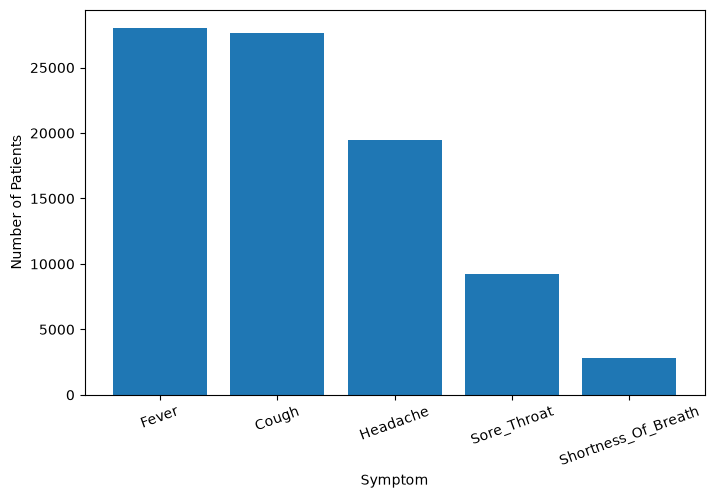

In [16]:
plt.figure(figsize=(8,5))

plt.bar(symptom_counts.index, symptom_counts.values)

#plt.title("Frequency of Reported COVID-19 Symptoms")
plt.xlabel("Symptom")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)
plt.savefig("Figure3.png", dpi=300, bbox_inches="tight")
plt.show()

From the reported symptoms, fever (27,367) was the most frequently reported. Shortness of breaths (2,740) was the least reported symptom.

The frequency of a symptom by itself does not indicate a positive COVID-19 diagnosis; therefore, the next stage of the EDA looks at the relationship between each symptom and the COVID-19 test result.

### Relationship Between Symptoms and Test Results

This section looks at the relationship between each symptom and the COVID-19 test result by comparing the proportion of positive test results among individuals with and without each symptom.

In [17]:
# Calculate the positive-test rate among patients reporting each symptom
symptom_positive = []

for symptom in symptom_cols:
    positive_rate = (
        df[df[symptom] == 1]["Result"]
        .eq("positive")
        .mean() * 100
    )

    symptom_positive.append(positive_rate)

symptom_df = pd.DataFrame({
    "Symptom": symptom_cols,
    "Positive Rate (%)": symptom_positive
})

symptom_df = symptom_df.sort_values(
    by="Positive Rate (%)",
    ascending=False
)

symptom_df

,Symptom,Positive Rate (%)
4,Headache,86.147920
3,Shortness_Of_Breath,85.035714
2,Sore_Throat,84.987580
1,Fever,67.469923
0,Cough,58.010570


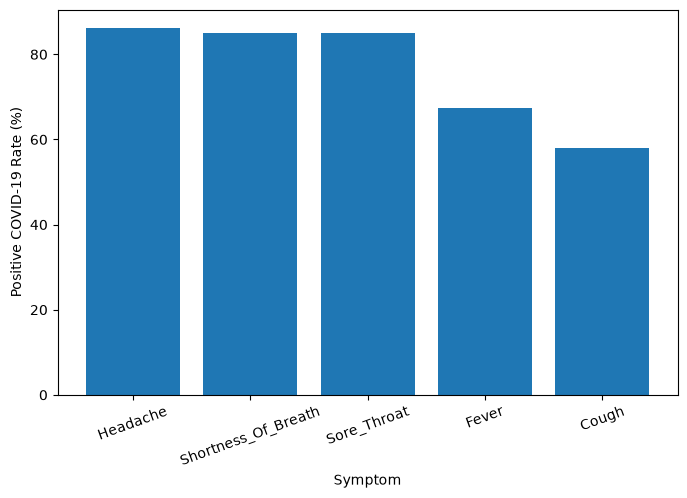

In [18]:
# Plot positive COVID-19 rates for each reported symptom
plt.figure(figsize=(8,5))

plt.bar(
    symptom_df["Symptom"],
    symptom_df["Positive Rate (%)"]
)

#plt.title("Positive COVID-19 Rate by Reported Symptom")
plt.xlabel("Symptom")
plt.ylabel("Positive COVID-19 Rate (%)")
plt.xticks(rotation=20)
plt.savefig("Figure4.png", dpi=300, bbox_inches="tight")
plt.show()

Patients reporting **headache** had the highest positive test rate (86.09%). Although more than half of the individuals reported having a cough (58.33%), **cough** was the lowest positive rate among the symptoms assessed. This suggest that not all symptoms equally lead to a positive test result.

### Contact vs. Test Result

Individuals who have had contact with infected persons are expected to have a higher probability of testing positive.

In [19]:
# Compare test-result percentages for each contact-history group
contact_result = pd.crosstab(
    df["Contact"],
    df["Result"],
    normalize="index"
) * 100

contact_result

Result,negative,positive
Contact,,
0,93.174783,6.825217
1,39.243717,60.756283


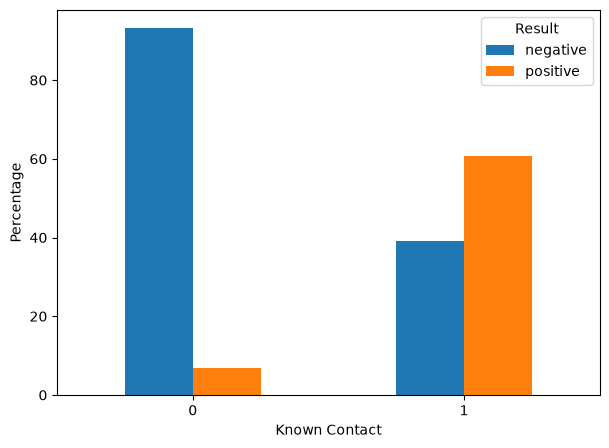

In [20]:
# Plot the test-result distribution by known-contact status
contact_result.plot(
    kind="bar",
    figsize=(7,5)
)

#plt.title("COVID-19 Test Result by Contact History")
plt.ylabel("Percentage")
plt.xlabel("Known Contact")
plt.xticks(rotation=0)
plt.savefig("Figure5.png", dpi=300, bbox_inches="tight")
plt.show()

There is a strong association between exposure and infection. Among individuals with **no contact**, **93%** tested **negative**, while **7%** tested **positive**. Individuals with **known contact**, **61%** tested positive and **39%** tested **negative**. This suggests that contact with a person confirmed to have COVID-19 is a strong predictor of a positive test result.

### Correlation Analysis

A correlation matrix is used to examine the relationships among the predictor variables.

In [21]:
# Create a temporary copy
temp = df.copy()

In [22]:
# Convert the target variable to numeric
temp["Result_Num"] = temp["Result"].map({
    "negative": 0,
    "positive": 1
})

In [23]:
# Select variables for correlation analysis
corr_cols = [
    "Cough",
    "Fever",
    "Sore_Throat",
    "Shortness_Of_Breath",
    "Headache",
    "Age_60_And_Above",
    "Contact",
    "Result_Num"
]

In [24]:
# Convert Age_60_And_Above from Yes/No to 1/0
temp["Age_60_And_Above"] = temp["Age_60_And_Above"].map({
    "Yes": 1,
    "No": 0
})

In [25]:
# Drop rows with missing values in the selected columns
corr_data = temp[corr_cols].dropna()

In [26]:
# Compute correlation matrix
corr_matrix = corr_data.corr()

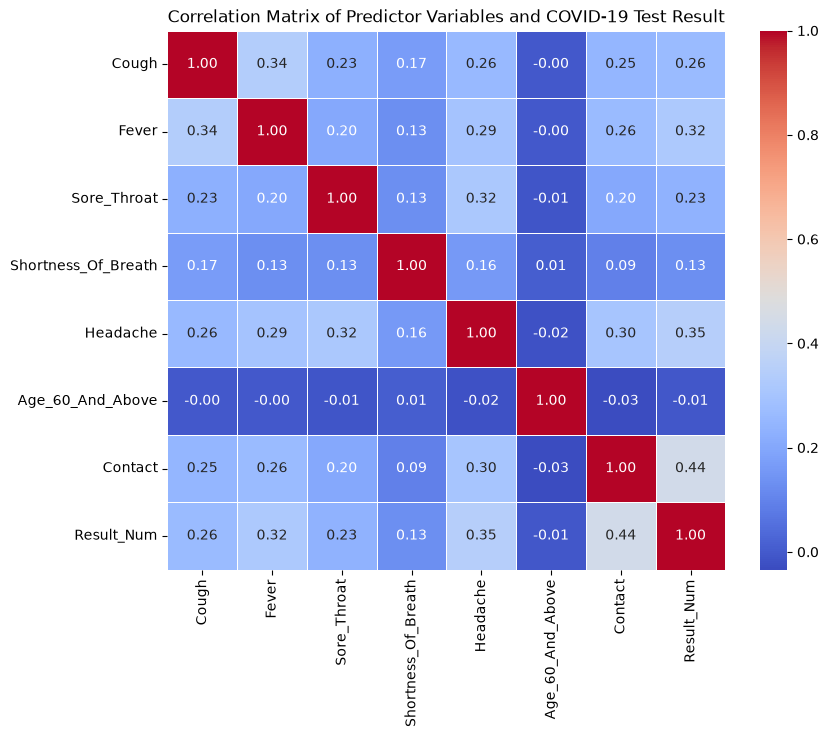

In [27]:
# Plot heatmap
plt.figure(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Predictor Variables and COVID-19 Test Result")
plt.savefig("Figure6.png", dpi=300, bbox_inches="tight")
plt.show()

The correlation matrix shows that most predictor variables have weak positive correlations with one another, suggesting that each variable uniquely correlates to a positive test result. The strongest relationship with the target variable is **Contact** (r = 0.44). This indicates that contact with an infected individual is the strongest predictor of a positive COVID-19 test result. From the symptoms, **Headache** (r = 0.35) and **Fever** (r = 0.32) have the strongest correlations with a positive test result. Since no pair has a strong correlation, multicollinearity is unlikely to be a factor for the models developed.

### Age (60+) vs. Test Result

This section looks at the relationship between age and COVID-19 test results. This helps determine if age is associated with an increased chance of testing positive for COVID-19.

In [28]:
age_result = pd.crosstab(
    df["Age_60_And_Above"],
    df["Result"],
    normalize="index"
) * 100

age_result

Result,negative,positive
Age_60_And_Above,,
No,89.387819,10.612181
Yes,89.987656,10.012344


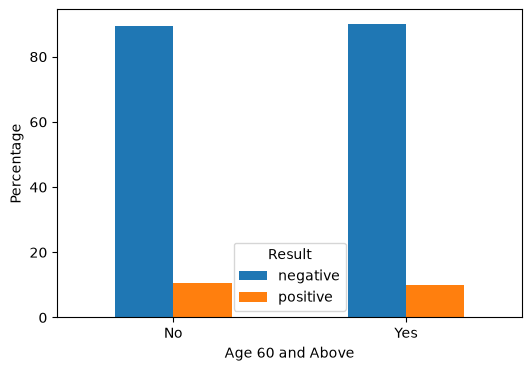

In [29]:
age_result.plot(
    kind="bar",
    figsize=(6,4)
)

#plt.title("COVID-19 Test Result by Age Group")
plt.xlabel("Age 60 and Above")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.savefig("Figure7.png", dpi=300, bbox_inches="tight")
plt.show()

The relationship between age and test results shows no meaningful difference between individuals over and under sixty. About **10.61%** of individuals under sixty tested positive. About **10.01%** of individuals sixty and above tested positive. This suggests that the **Age_60_And_Above** variable has little connection with positive test results.

### Sex vs. Test Results

This section looks at the relationship between an individual's sex and test results. This helps determine if sex is associated with a positive test result and if it may be a point of influence for the classification models later developed.

In [30]:
# Compare test-result percentages for male and female patients
sex_result = pd.crosstab(
    df["Sex"],
    df["Result"],
    normalize="index"
) * 100

sex_result

Result,negative,positive
Sex,,
female,90.510815,9.489185
male,88.996917,11.003083


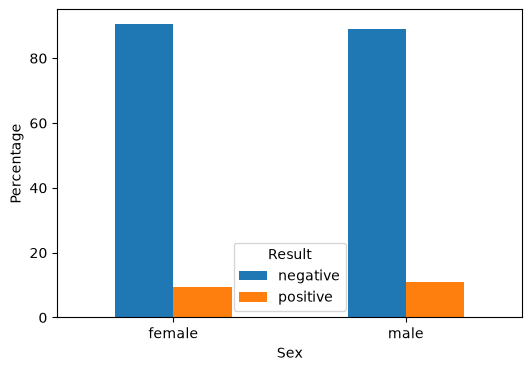

In [31]:
# Plot the test-result distribution by sex
sex_result.plot(
    kind="bar",
    figsize=(6,4)
)

#plt.title("COVID-19 Test Result by Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.savefig("Figure8.png", dpi=300, bbox_inches="tight")
plt.show()

The relationship between sex and test results shows a small difference in positive test rates between male and female individuals. About **11.32% of males tested positive** for COVID-19, while **9.78% of females** tested positive for COVID-19. Although males were more likely to test positive compared to females, the difference between the two is small. This suggests that sex may only moderately influence the predictive models. 

## Data preparation

This section prepares the dataset for modeling. Categorical variables are converted into binary numeric values. Missing values are removed and the data is partitioned into training/testing sets.

### Missing Data Handling

Missing values are removed from the Age_60_And_Above and Sex variables.

In [32]:
# Create a copy so the original dataframe remains unchanged
clean_df = df.copy()

In [33]:
# Display the dataset size before removing missing values
print(f"Rows before cleaning: {clean_df.shape[0]:,}")

Rows before cleaning: 1,030,724


In [34]:
# Remove rows with missing values in the demographic variables
clean_df = clean_df.dropna(
    subset=["Age_60_And_Above", "Sex"]
).copy()

In [35]:
# Display the dataset size after removing missing values
print(f"Rows after cleaning: {clean_df.shape[0]:,}")
print(f"Rows removed: {df.shape[0] - clean_df.shape[0]:,}")

Rows after cleaning: 978,493
Rows removed: 52,231


In [36]:
# Confirm that the cleaned dataframe contains no missing values
clean_df.isna().sum()

Cough                  0
Fever                  0
Sore_Throat            0
Shortness_Of_Breath    0
Headache               0
Age_60_And_Above       0
Sex                    0
Contact                0
Result                 0
dtype: int64

### Variable Encoding

The Age_60_And_Above, Sex, and Result variables are text variable; thereore, they must be converted into numeric values before creating the models. Yes values are encoded as 1. Positive values are encoded as 1. Male values are encoded as 1. Alternate values for these categories are encoded as 0.

In [37]:
# Convert text-based binary variables to numeric values for age
clean_df["Age_60_And_Above"] = clean_df["Age_60_And_Above"].map({
    "Yes": 1,
    "No": 0
})

In [38]:
# Convert text-based binary variables to numeric values for sex
clean_df["Sex"] = clean_df["Sex"].map({
    "male": 1,
    "female": 0
})

In [39]:
# Convert text-based binary variables to numeric values for final result
clean_df["Result"] = clean_df["Result"].map({
    "positive": 1,
    "negative": 0
})

In [40]:
# Verify encoded values
for column in ["Age_60_And_Above", "Sex", "Result"]:
    print(f"{column}: {sorted(clean_df[column].unique())}")

Age_60_And_Above: [0, 1]
Sex: [0, 1]
Result: [0, 1]


## 4. Modeling

### 4.1 Logistic Regression

In [41]:
import statsmodels.formula.api as smf
from statsmodels.api import families
from sklearn.model_selection import train_test_split

In [42]:
TData, VData = train_test_split(
    clean_df,
    test_size=0.40,
    random_state=321,
    stratify=clean_df["Result"]
)

print(TData.shape)
print(VData.shape)

(587095, 9)
(391398, 9)


In [43]:
Model1 = smf.glm(
    "Result ~ Cough + Fever + Sore_Throat + Shortness_Of_Breath + "
    "Headache + Age_60_And_Above + Sex + Contact",
    family=families.Binomial(),
    data=TData
).fit()

Model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 Result   No. Observations:               587095
Model:                            GLM   Df Residuals:                   587086
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4789e+05
Date:                Wed, 22 Jul 2026   Deviance:                   2.9579e+05
Time:                        22:48:08   Pearson chi2:                 7.65e+05
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1558
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.9261      0.008   -354.080      0.000      -2.942      -2.910
Cough                   0.9635      0.023     41.143      0.000       0.918       1.009
Fever                   1.8024      0.023     78.976      0.000       1.758       1.847
Sore_Throat             1.9455      0.047     41.024      0.000       1.853       2.038
Shortness_Of_Breath     1.7655      0.084     20.969      0.000       1.600       1.931
Headache                2.5828      0.032     80.342      0.000       2.520       2.646
Age_60_And_Above        0.1036      0.015      7.049      0.000       0.075       0.132
Sex                     0.2626      0.010     25.957      0.000       0.243       0.282
Contact                 2.5056      0.013    188.945      0.000       2.480       2.532
=======================================================================================
"""

**Abbreviation Key**

- TP = True Positive
- TN = True Negative
- FP = False Positive
- FN = False Negative

- TPR = True Positive Rate (Sensitivity/Recall)
- FPR = False Positive Rate
- TNR = True Negative Rate (Specificity)
- FNR = False Negative Rate

- ROC = Receiver Operating Characteristic
- AUC = Area Under the ROC Curve

- pHat = Predicted Probability
- yHat = Predicted Class
- yTrue = Actual (Observed) Class

In [44]:
pHat1 = Model1.predict(VData)

pHat1.head()

21853     0.050879
729890    0.050879
964772    0.050879
817976    0.050879
231762    0.065162
dtype: float64

In [45]:
yHat1 = np.where(pHat1 >= 0.50, 1, 0)

yHat1[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [46]:
yTrue1 = VData["Result"].values

In [47]:
from sklearn.metrics import confusion_matrix

CM1 = confusion_matrix(yTrue1, yHat1)

print(CM1)

[[347256   2929]
 [ 30223  10990]]


In [48]:
yTP1 = np.where(
    (yTrue1 == 1) & (yHat1 == 1),
    1,
    0
)

In [49]:
yFN1 = np.where(
    (yTrue1 == 1) & (yHat1 == 0),
    1,
    0
)

In [50]:
yTN1 = np.where(
    (yTrue1 == 0) & (yHat1 == 0),
    1,
    0
)

In [51]:
yFP1 = np.where(
    (yTrue1 == 0) & (yHat1 == 1),
    1,
    0
)

In [52]:
Sensitivity1 = np.sum(yTP1) / (
    np.sum(yTP1) + np.sum(yFN1)
)

print("Sensitivity =", round(Sensitivity1, 4))

Sensitivity = 0.2667


In [53]:
Specificity1 = np.sum(yTN1) / (
    np.sum(yTN1) + np.sum(yFP1)
)

print("Specificity =", round(Specificity1, 4))

Specificity = 0.9916


In [54]:
Precision1 = np.sum(yTP1) / (
    np.sum(yTP1) + np.sum(yFP1)
)

print("Precision =", round(Precision1, 4))

Precision = 0.7896


In [55]:
Accuracy1 = (
    np.sum(yTP1) + np.sum(yTN1)
) / len(yTrue1)

print("Accuracy =", round(Accuracy1, 4))

Accuracy = 0.9153


In [56]:
F1_1 = 2 * (
    (Precision1 * Sensitivity1) /
    (Precision1 + Sensitivity1)
)

print("F1-score =", round(F1_1, 4))

F1-score = 0.3987


In [57]:
from sklearn.metrics import roc_auc_score

AUC1 = roc_auc_score(yTrue1, pHat1)

print("ROC AUC =", round(AUC1,4))

ROC AUC = 0.7692


### 4.2 K-Nearest Neighbors

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Use the data that has already been cleaned
myData = clean_df.copy()

# Use a sample of the data instead of the full thing because
# KNN scales quickly with more data and there are 1M rows
myData, _ = train_test_split(myData,
                             train_size = 50000,
                             stratify = myData.Result,
                             random_state = 321)

# split into train (60%) and test (40%), stratified since only ~10% are positive cases
X_train, X_test, y_train, y_test = train_test_split(myData.drop('Result', axis = 1),
                                                    myData.Result,
                                                    test_size = 0.40,
                                                    stratify = myData.Result,
                                                    random_state = 321)

# standardize the predictors
scaler = StandardScaler()
dataScaler = scaler.fit(X_train)

X_train_std = dataScaler.transform(X_train)
X_test_std = dataScaler.transform(X_test)

In [59]:
# 10-fold cross validation over k = 1 to 20, using accuracy
KNN_model = KNeighborsClassifier()
paramGrid = {'n_neighbors': range(1, 20 + 1)}

search = GridSearchCV(KNN_model,
                      paramGrid,
                      cv = 10,
                      scoring = 'accuracy')

KNN_fit = search.fit(X_train_std, y_train)

pd.DataFrame(KNN_fit.cv_results_).sort_values('rank_test_score')[['param_n_neighbors', 'mean_test_score', 'rank_test_score']]

,param_n_neighbors,mean_test_score,rank_test_score
11,12,0.919267,1
19,20,0.919000,2
17,18,0.918933,3
8,9,0.918800,4
10,11,0.918767,5
18,19,0.918667,6
16,17,0.918633,7
14,15,0.918567,8
15,16,0.918500,9
12,13,0.918400,10


In [60]:
# The optimal value of k
KNN_fit.best_estimator_

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",12
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [61]:
# Predict and evaluate
testPredictions = KNN_fit.predict(X_test_std)

from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, testPredictions)

array([[17504,   390],
       [ 1259,   847]])

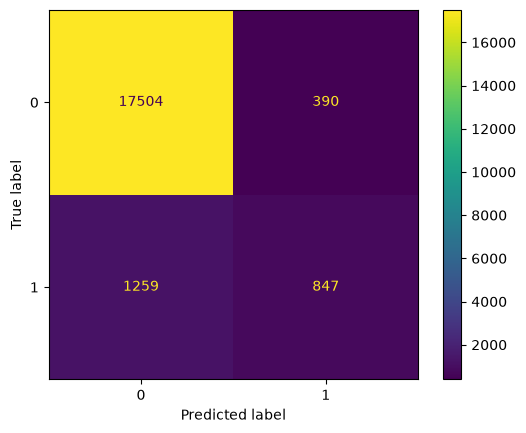

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, testPredictions);

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test,
                            testPredictions,
                            target_names = ['Negative', 'Positive'],
                            digits = 4))

              precision    recall  f1-score   support

    Negative     0.9329    0.9782    0.9550     17894
    Positive     0.6847    0.4022    0.5067      2106

    accuracy                         0.9175     20000
   macro avg     0.8088    0.6902    0.7309     20000
weighted avg     0.9068    0.9175    0.9078     20000



In [64]:
testPredictionProbs = KNN_fit.predict_proba(X_test_std)

In [65]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, testPredictionProbs[:,1])

0.7680987202148858

## 5. Evaluation

Two classification models were developed with the purpose of predicting if a patient would likely test positive for COVID-19. Both the Logistic Regression and K-Nearest Neighbors models were trained and tested using the same proportion of data. The model performance evaluation focused on criteria including ROC AUC, accuracy, and precision to name a few. Both models performed very similarly. The difference in accuracy was only 0.22% favoring the KNN model. The difference in ROC AUC values was less than 0.002. This indicates that both models were nearly identical in their ability to correctly identify positive and negative cases. Based solely on these metrics, neither model demonstrated an edge in performance.  
The primary gaps in performance between the models existed in their precision and sensitivity. The Logistic Regression model led with a higher precision of 78.96% versus the KNN model’s 68.47%. This value indicates the Logistic Regression model was more likely to be correct when identifying a positive case compared to the KNN model. However, the KNN model had a higher sensitivity of 40.22% versus the Logistic Regression model’s 26.67%. This indicates the KNN model correctly identified about 51% more positive cases compared to the other model. The KNN also had a better F1-score which means the model also had a better balance between precision and sensitivity.  
The K-Nearest Neighbors model outperformed the Logistic Regression model. Based on their metrics, the KNN model is the better model for the COVID-19 dataset. The Logistic Regression model did have fewer false positives; however, the KNN model’s better sensitivity makes it the optimal choice for identifying infected patients.

## 6. Deployment

The results of the KNN model can be extrapolated to support decisions made in the healthcare sector. From the exploratory data analysis, contact with a person who was diagnosed as having COVID-19 was the strongest predictor variable in determining if a person would also test positive. Symptoms of headaches and fever had the strongest positive correlation with positive test results. Healthcare professionals can use this information to pay extra attention to patients exhibiting these two symptoms.   
The models showed that the symptom data can be a useful guide to determine if someone is likely to test positive but not definitive. Both models achieved a similar accuracy at approximately 91% but neither accomplished identifying all positive cases. From these results, laboratory testing still proves vital in confirming the final diagnosis. The models should not replace laboratory testing. Instead, the models could be used to identify patients likely to test positive to “recommended to stay at home for 5 days” (2023) until additional testing can be done or in times of limited resources. 

## 7. Conclusion

This analysis showed that machine learning models can be used to determine if a person is likely to test positive for COVID-19 based solely on a list of five reported symptoms and information regarding the individuals’ demographics. Two classification models were compared regarding accuracy and ROC AUC values. The K-Nearest Neighbors model had a higher sensitivity over the Logistic Regression model; therefore, the KNN model was selected to be the better model of the two. The KNN model identified a larger proportion of positive cases. The results indicate that symptom and patient demographic information can provide a supplemental tool to healthcare workers to fast-track individuals to be tested. 
One known limitation of the analysis conducted in the handling of missing data. Records with missing data hovered around the 5% threshold where removing the records could potentially skew the predictive model’s effectiveness. Chi-square tests were performed to identify relationships between missing variables, but this does not confirm whether the missing data points were random. In the case the missing data was not Missing Completely at Random (MCAR), “we may [not] consequently ignore many of the complexities that arise” (2018). Future evaluations could explore alternative methods for handling the missing data. Additionally, the dataset was imbalanced. Only 10% of the patients represented a positive case for the target variable. This likely affected both model’s ability to identify positive cases. The KNN model was also limited to a sample of the dataset. Because the dataset contained over one million records, processing all the records was too computationally expensive. 
Overall, the analysis showed that both models can be used to support COVID-19 screening with the KNN model being favorable. 
